# US Traffic Road Accident Risk Factors and Hotspot Analysis

## Objective:
The objective of this project was to analyze US traffic accident data to identify and understanf the factors influencing traffic accidents in the United States by examining temporal patterns, environmental conditions, and road infrastructure. This project also focuses on identifying accident hotspots and to understand how traffic conditions impact accident frequency and severity.

## Dataset Overview:

The dataset used in this project is the **US Accidents (2016–2023)** dataset. It is a large-scale, countrywide traffic accident dataset that contains detailed information about road accidents across the United States.

### Key Dataset Characteristics:

#### 
- **Coverage:** 49 states across the United States  
- **Time Period:** February 2016 – March 2023  
- **Number of Records:** ~7.7 million accident records  
- **Data Format:** CSV file  
- **Number of Features:** ~46 attributes depending on dataset version
- **Dataset Credit:**
- Moosavi, S., Samavatian, M. H., Parthasarathy, S., & Ramnath, R. (2019). A Countrywide Traffic Accident Dataset.
- Moosavi, S., Samavatian, M. H., Parthasarathy, S., Teodorescu, R., & Ramnath, R. (2019). Accident Risk Prediction based on Heterogeneous S

### Types of Variables Included in the dataset:

The dataset contains several categories of variables:

**1. Accident Information**
- Severity level of the accident
- Start and end time of the incident
- Duration of traffic disruption

**2. Geographic Information**
- Latitude and longitude coordinates
- City, county, and state
- Street and road location

**3. Weather Conditions**
- Temperature
- Humidity
- Visibility
- Wind speed
- Precipitation
- Weather condition description

**4. Road Infrastructure Indicators**
- Presence of junctions
- Traffic signals
- Railway crossings
- Stop signs
- Speed bumps

**5. Time-Based Features**
- Hour of the day
- Day of the week
- Month and season
- Daylight conditions (sunrise/sunset, twilight, etc)

## Step 1: Importing the required libraries
- **Pandas** – data manipulation and analysis  
- **NumPy** – numerical operations  
- **Matplotlib & Seaborn** – data visualization  
- **Folium** – geospatial visualization and accident hotspot mapping

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Step 2: Data Loading

The dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [95]:
path = 'C:/Users/shubh/Desktop/Simran/Project/Prodigy-info-tech/Project-4/US_Accidents_March23.csv'
df = pd.read_csv(path)
print(df)

                ID   Source  Severity           Start_Time  \
0              A-1  Source2         3  2016-02-08 05:46:00   
1              A-2  Source2         2  2016-02-08 06:07:59   
2              A-3  Source2         2  2016-02-08 06:49:27   
3              A-4  Source2         3  2016-02-08 07:23:34   
4              A-5  Source2         2  2016-02-08 07:39:07   
...            ...      ...       ...                  ...   
7728389  A-7777757  Source1         2  2019-08-23 18:03:25   
7728390  A-7777758  Source1         2  2019-08-23 19:11:30   
7728391  A-7777759  Source1         2  2019-08-23 19:00:21   
7728392  A-7777760  Source1         2  2019-08-23 19:00:21   
7728393  A-7777761  Source1         2  2019-08-23 18:52:06   

                    End_Time  Start_Lat   Start_Lng   End_Lat    End_Lng  \
0        2016-02-08 11:00:00  39.865147  -84.058723       NaN        NaN   
1        2016-02-08 06:37:59  39.928059  -82.831184       NaN        NaN   
2        2016-02-08 07:19:2

## Step 3: Initial Data Inspection

Before performing the data cleaning, it is important to inspect the structure and data quality.

#### 3.1 Checking the dataset shape 

In [96]:
df.shape

(7728394, 46)

#### 3.2 Checking the first few rows

In [97]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


#### 3.3 Checking the last few rows

In [98]:
df.tail()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.00248,-117.37936,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.76696,-117.14806,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.77545,-117.84779,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.99246,-118.40302,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day
7728393,A-7777761,Source1,2,2019-08-23 18:52:06,2019-08-23 19:21:31,34.13393,-117.23092,34.13736,-117.23934,0.537,...,False,False,False,False,False,False,Day,Day,Day,Day


#### 3.3 Checking the Column names

In [99]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

#### 3.4 Statistical Summary of Data

In [100]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


#### 3.5 Checking the data type and memory usage

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

#### Memory Usage Observation:
The dataset currently uses **approximately 2.0 GB of memory**, which is relatively large for in-memory data processing.
-  High memory usage can **slow down data processing and analysis**
-  Large datasets may also lead to **performance limitations on systems with limited RAM**.
-  To improve efficiency, **data optimization techniques will be applied in the preprocessing stage**.
- Reducing memory usage will help make the dataset **more manageable and improve computational performance** during analysis.

## Step 4: Initial Missing Value Analysis (Before Cleaning)

In [102]:
df.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [103]:
# Checking missing values in percentage in the data set
(df.isnull().sum()/len(df))*100

ID                        0.000000
Source                    0.000000
Severity                  0.000000
Start_Time                0.000000
End_Time                  0.000000
Start_Lat                 0.000000
Start_Lng                 0.000000
End_Lat                  44.029355
End_Lng                  44.029355
Distance(mi)              0.000000
Description               0.000065
Street                    0.140637
City                      0.003274
County                    0.000000
State                     0.000000
Zipcode                   0.024779
Country                   0.000000
Timezone                  0.101030
Airport_Code              0.292881
Weather_Timestamp         1.555666
Temperature(F)            2.120143
Wind_Chill(F)            25.865904
Humidity(%)               2.253301
Pressure(in)              1.820288
Visibility(mi)            2.291524
Wind_Direction            2.267043
Wind_Speed(mph)           7.391355
Precipitation(in)        28.512858
Weather_Condition   

## Step 5: Checking for duplicate values

In [104]:
df.duplicated().sum()

np.int64(0)

**No duplicate records found in the dataset, indicating all the entries are unique**

## Step 7: Data Cleaning



#### 7.1 Removing or dropping the columns which are not useful for analysis.

To improve data quality and reduce unnecessary complexity, several columns were removed from the dataset.

**Irrelevant Columns Removed**
- **ID** – Unique identifier, not useful for analysis.
- **Source** – Indicates dataset origin only.
- **Timezone** – Redundant since location information is already available.
- **Airport_Code** – Only maps the nearest weather station.
- **Zipcode** – Too granular for this analysis.
- **Description** – Free-text field not used in structured analysis.

**Columns Removed Due to High Missing Values**
- **End_Lat** and **End_Lng** – ~44% missing values and redundant since the accident location is already captured by start coordinates.
- **Wind_Chill(F)** – ~26% missing values and largely overlaps with temperature information.

In [105]:
df = df.drop(columns=['ID', 'Source','Street', 'Timezone','Airport_Code','Zipcode','Description','End_Lat','End_Lng','Wind_Chill(F)'])

#### Checking if the Columns are removed from the data set

In [106]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'City', 'County', 'State', 'Country',
       'Weather_Timestamp', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

#### 7.2 Handling the Missing Values in the data set

After removing irrelevant columns, the remaining missing values were handled using appropriate imputation techniques depending on the type of variable.

**Numerical Variables - Median Imputation**  
- For continuous weather-related variables such as **temperature, humidity, pressure, visibility, wind speed, and precipitation**, missing values were imputed using the **median**.
- Median imputation is robust to outliers and preserves the overall distribution of the data.

**Categorical Variables - Mode Imputation**  
- Categorical features such as **Wind_Direction, Weather_Condition, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, and Astronomical_Twilight** were imputed using the **mode**, which replaces missing values with the most frequently occurring category.

**Time-Based Data - Forward Fill**  
- For the **Weather_Timestamp** column, missing values were handled using **forward fill (ffill)**. 
- This method propagates the last valid observation forward, ensuring continuity in time-based weather observations.


These imputation techniques help retain a large portion of the dataset while maintaining the integrity and statistical characteristics of the variables.

#### 7.2.1 Imputing the Numerical Variables with Median

In [107]:
# Temperature:
df['Temperature(F)'].fillna(df['Temperature(F)'].median(),inplace = True)

# Humidity:
df['Humidity(%)'].fillna(df['Humidity(%)'].median(),inplace= True)

# Pressure:
df['Pressure(in)'].fillna(df['Pressure(in)'].median(), inplace = True)

# Visibility:
df['Visibility(mi)'].fillna(df['Visibility(mi)'].median(), inplace = True)

# Precipitation:Missing values were replaced with 0, assuming that the absence of recorded precipitation indicates dry weather conditions.
df['Precipitation(in)'].fillna(df['Precipitation(in)'].fillna(0),inplace = True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\252245707.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\252245707.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

#### 7.2.2 Imputing the Categorical Variables with Mode

In [108]:
# Wind_Speed(mph)           
df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].mode()[0],inplace = True)

# Wind_Direction
df['Wind_Direction'].fillna(df['Wind_Direction'].mode()[0],inplace = True)

# Weather_Condition
df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0],inplace = True)

# Sunrise_Sunset
df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode()[0],inplace = True)

# Civil_Twilight
df['Civil_Twilight'].fillna(df['Civil_Twilight'].mode()[0],inplace = True)

# Nautical Twilight
df['Nautical_Twilight'].fillna(df['Nautical_Twilight'].mode()[0],inplace = True)

# Astronomical Twilight
df['Astronomical_Twilight'].fillna(df['Astronomical_Twilight'].mode()[0],inplace = True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\439201308.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\439201308.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

#### 7.2.3 Imputing the Time-based Variable with forward fill

In [109]:
df['Weather_Timestamp'].fillna(df['Weather_Timestamp'].fillna(method='ffill'),inplace = True)

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\3636201812.py:1: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\3636201812.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





#### 7.2.4 Dropping the subsets of dataset will null values

In [110]:
#Dropping the rows with missing timestamp
df = df.dropna(subset=['Start_Time','End_Time'])
df = df.dropna(subset=['City'])

In [111]:
#Checking the missing value percentage
(df.isnull().sum()/len(df))*100

Severity                 0.0
Start_Time               0.0
End_Time                 0.0
Start_Lat                0.0
Start_Lng                0.0
Distance(mi)             0.0
City                     0.0
County                   0.0
State                    0.0
Country                  0.0
Weather_Timestamp        0.0
Temperature(F)           0.0
Humidity(%)              0.0
Pressure(in)             0.0
Visibility(mi)           0.0
Wind_Direction           0.0
Wind_Speed(mph)          0.0
Precipitation(in)        0.0
Weather_Condition        0.0
Amenity                  0.0
Bump                     0.0
Crossing                 0.0
Give_Way                 0.0
Junction                 0.0
No_Exit                  0.0
Railway                  0.0
Roundabout               0.0
Station                  0.0
Stop                     0.0
Traffic_Calming          0.0
Traffic_Signal           0.0
Turning_Loop             0.0
Sunrise_Sunset           0.0
Civil_Twilight           0.0
Nautical_Twili

#### Now our data set is cleaned properly

## Step 8: Data Preprocessing

### 8.1 Data Optimization and 

**Categorical Conversion**  
- Columns such as **City, County, State, Weather_Condition, Wind_Direction, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, and Astronomical_Twilight** were converted to the **category** data type. This significantly reduces memory usage since these columns contain a limited set of repeated values.

**Boolean Encoding**  
- Binary variables representing the presence or absence of road features (e.g., Junction, Traffic_Signal, Stop, Railway) were converted from **True/False values to 0 and 1**. This transformation simplifies analysis and improves compatibility with statistical operations and machine learning algorithms.

**Datetime Conversion**  
- The columns **Start_Time, End_Time, and Weather_Timestamp** were converted to **datetime format** using `pd.to_datetime()`. This allows extraction of time-based features such as hour, day, month, and season, which are essential for temporal accident analysis.


In [112]:
### Converting the following columns into categorical columns for memory reduction

categorical_cols = ['City','County','State','Weather_Condition','Wind_Direction','Sunrise_Sunset','Civil_Twilight',
'Nautical_Twilight','Astronomical_Twilight']

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [113]:
### Converting the following columns into Binary (0 and 1) for better analytical compatibilty

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction','No_Exit','Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop']

for col in bool_cols:
    df[col] = df[col].astype(int)

In [114]:
### Converting the time columns in datetime format

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')

#### Checking the overall data and memory usage.

In [115]:
df.shape

(7728141, 36)

In [116]:
df.head()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Country,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US,...,0,0,0,0,0,0,Night,Night,Night,Night
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US,...,0,0,0,0,0,0,Night,Night,Night,Day
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US,...,0,0,0,0,1,0,Night,Night,Day,Day
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US,...,0,0,0,0,0,0,Night,Day,Day,Day
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US,...,0,0,0,0,1,0,Day,Day,Day,Day


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7728141 entries, 0 to 7728393
Data columns (total 36 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Severity               int64         
 1   Start_Time             datetime64[ns]
 2   End_Time               datetime64[ns]
 3   Start_Lat              float64       
 4   Start_Lng              float64       
 5   Distance(mi)           float64       
 6   City                   category      
 7   County                 category      
 8   State                  category      
 9   Country                object        
 10  Weather_Timestamp      datetime64[ns]
 11  Temperature(F)         float64       
 12  Humidity(%)            float64       
 13  Pressure(in)           float64       
 14  Visibility(mi)         float64       
 15  Wind_Direction         category      
 16  Wind_Speed(mph)        float64       
 17  Precipitation(in)      float64       
 18  Weather_Condition      cate

After performing data cleaning and preprocessing steps such as removing irrelevant columns and optimizing data types, the dataset size was reduced from **2.4 GB to 1.7 GB**, resulting in approximately **29% reduction in memory usage**.

## Step 9: Feature Enginnering

### 1. Accident Duration
To understand how long each accident affected traffic, we calculate the accident duration by subtracting the accident **start time** from the **end time** and converted the difference into minutes.

In [118]:
df['Accident_Duration_Min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

### 2. Day of Week
- Traffic patterns often vary depending on the day of the week.To capture this pattern, we extracted the **day name** from the accident start time.
-This feature allows us to analyze whether accidents occur more frequently on certain days such as weekdays or weekends.

In [119]:
df['Day_of_Week'] = df['Start_Time'].dt.day_name()

### 3. Weekend Indicator
- Accident patterns can differ significantly between weekdays and weekends due to changes in traffic volume and travel behavior.

To capture this, we created a **Weekend feature** where:
- **1** indicates the accident occurred on Saturday or Sunday
- **0** indicates the accident occurred on a weekday

In [120]:
df['Weekend'] = (df['Start_Time'].dt.dayofweek >= 5).astype(int)

### 4. Month Feature
- We extracted the month from the accident start time to analyze how accident frequency changes throughout the year.

In [121]:
df['Month'] = (df['Start_Time'].dt.month_name())

### 5. Year Feature
-The year was extracted from the accident start time to observe long-term accident trends.
-This feature helps analyze whether accident frequency increases or decreases over the years.

In [122]:
df['Year'] = (df['Start_Time'].dt.year)

### 6. Time of Day
Accident likelihood often depends on the time of day. For example, rush hours and nighttime driving conditions can increase accident risk.

To capture this pattern, we grouped hours into four categories:
- Morning
- Afternoon
- Evening
- Night

In [123]:
df['Hour'] = df['Start_Time'].dt.hour

def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time_of_Day'] = df['Hour'].apply(time_of_day)

### 7. Season Feature

Weather conditions vary significantly across seasons, which can influence road safety.

To capture seasonal trends in accidents, we grouped months into four seasons:
- Winter
- Spring
- Summer
- Fall

In [124]:
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

df['Season'] = df['Month'].apply(season)

### 8. Visibility Level

Poor visibility can significantly increase the risk of accidents.  
To better analyze this effect, we categorized visibility into three levels:

- Low visibility
- Medium visibility
- High visibility

This makes it easier to compare accident patterns across different visibility conditions.

In [125]:
def visibility_level(v):
    if v <= 2:
        return "Low"
    elif v <= 5:
        return "Medium"
    else:
        return "High"

df['Visibility_Level'] = df['Visibility(mi)'].apply(visibility_level)

### 9. Wind Speed Level

Strong winds can affect vehicle stability and driving conditions.  
To capture this effect, wind speeds were grouped into three categories:

- Low wind
- Moderate wind
- High wind

In [126]:
def wind_level(w):
    if w <= 5:
        return "Low"
    elif w <= 15:
        return "Moderate"
    else:
        return "High"

df['Wind_Level'] = df['Wind_Speed(mph)'].apply(wind_level)

### 10. Weather Category

The dataset contains many detailed weather descriptions.  
To simplify analysis, these conditions were grouped into broader weather categories such as:

- Clear
- Cloudy
- Rain
- Snow
- Fog or Mist
- Storm
- Ice or Freezing conditions

This helps reduce complexity while still preserving meaningful weather patterns.

In [127]:
def categorize_weather(condition):
    condition = str(condition)

    if 'Clear' in condition or 'Fair' in condition:
        return 'Clear'
    elif 'Cloud' in condition or 'Overcast' in condition:
        return 'Cloudy'
    elif 'Rain' in condition or 'Drizzle' in condition or 'Shower' in condition:
        return 'Rain'
    elif 'Snow' in condition:
        return 'Snow'
    elif 'Fog' in condition or 'Mist' in condition or 'Haze' in condition or 'Smoke' in condition:
        return 'Fog / Mist'
    elif 'Thunder' in condition or 'T-Storm' in condition or 'Storm' in condition:
        return 'Storm'
    elif 'Ice' in condition or 'Sleet' in condition or 'Freezing' in condition:
        return 'Ice / Freezing'
    elif 'Dust' in condition or 'Sand' in condition or 'Tornado' in condition or 'Ash' in condition:
        return 'Dust / Sand'
    else:
        return 'Other'

df['Weather_Category'] = df['Weather_Condition'].apply(categorize_weather)

### 11. Severe Accident Indicator

To simplify the analysis of accident severity, we created a binary feature called **Severe Accident**.

- Value **1** represents severe accidents (severity 3 or 4)
- Value **0** represents less severe accidents

This feature is useful when building models that predict high-risk accidents.

In [128]:
df['Severe_Accident'] = df['Severity'].apply(lambda x: 1 if x >= 3 else 0)

### 12. Rush Hour Indicator

Traffic congestion during peak commuting hours can increase the likelihood of accidents.

To capture this effect, we created a **Rush Hour feature** that identifies accidents occurring during peak traffic periods:

- Morning rush hour: 7 AM – 9 AM
- Evening rush hour: 4 PM – 6 PM

In [129]:
df['Rush_Hour'] = df['Hour'].apply (lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

# Dataset Check:
This step is done to check if all the features are succesfully created and to check the memory usage.

In [130]:
df.shape

(7728141, 49)

10. Geospatial Analysis

In [131]:
df.head()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Country,...,Month,Year,Hour,Time_of_Day,Season,Visibility_Level,Wind_Level,Weather_Category,Severe_Accident,Rush_Hour
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US,...,February,2016.0,5.0,Morning,Fall,High,Low,Rain,1,0
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US,...,February,2016.0,6.0,Morning,Fall,High,Low,Rain,0,0
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US,...,February,2016.0,6.0,Morning,Fall,High,Low,Cloudy,0,0
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US,...,February,2016.0,7.0,Morning,Fall,High,Low,Cloudy,1,1
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US,...,February,2016.0,7.0,Morning,Fall,High,Low,Cloudy,0,1


In [132]:
df.describe()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),...,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Accident_Duration_Min,Weekend,Year,Hour,Severe_Accident,Rush_Hour
count,7.728141e+06,6985002,6985002,7.728141e+06,7.728141e+06,7.728141e+06,7728141,7.728141e+06,7.728141e+06,7.728141e+06,...,7.728141e+06,7.728141e+06,7.728141e+06,7728141.0,6.985002e+06,7.728141e+06,6.985002e+06,6.985002e+06,7.728141e+06,7.728141e+06
mean,2.212385e+00,2020-03-21 21:51:35.440544256,2020-03-22 04:58:28.516306688,3.620114e+01,-9.470297e+01,5.618247e-01,2020-06-04 02:50:50.197398784,6.171295e+01,6.487976e+01,2.954483e+01,...,2.773513e-02,9.831601e-04,1.479954e-01,0.0,4.268846e+02,1.383567e-01,2.019701e+03,1.226783e+01,1.946152e-01,3.687602e-01
min,1.000000e+00,2016-01-14 20:18:33,2016-02-08 06:37:08,2.455480e+01,-1.246238e+02,0.000000e+00,2016-01-14 19:51:00,-8.900000e+01,1.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.216667e+00,0.000000e+00,2.016000e+03,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2018-09-17 02:24:46,2018-09-17 05:26:12.500000,3.339957e+01,-1.172196e+02,0.000000e+00,2018-11-23 03:53:00,5.000000e+01,4.900000e+01,2.938000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,3.000000e+01,0.000000e+00,2.018000e+03,8.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2020-06-23 13:35:35,2020-06-23 15:20:03.500000,3.582392e+01,-8.776748e+01,3.000000e-02,2020-11-11 15:53:00,6.400000e+01,6.700000e+01,2.986000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,6.271667e+01,0.000000e+00,2.020000e+03,1.300000e+01,0.000000e+00,0.000000e+00
75%,2.000000e+00,2021-10-28 15:44:46.750000128,2021-10-29 14:58:34.500000,4.008499e+01,-8.035385e+01,4.640000e-01,2022-01-20 07:53:00,7.600000e+01,8.400000e+01,3.003000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1.226333e+02,0.000000e+00,2.021000e+03,1.700000e+01,0.000000e+00,1.000000e+00
max,4.000000e+00,2023-03-31 23:30:00,2023-03-31 23:59:00,4.900220e+01,-6.711317e+01,4.417500e+02,2023-03-31 23:53:00,2.070000e+02,1.000000e+02,5.863000e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,0.0,2.812939e+06,1.000000e+00,2.023000e+03,2.300000e+01,1.000000e+00,1.000000e+00
std,4.875279e-01,NaN,NaN,5.076091e+00,1.739176e+01,1.776794e+00,NaN,1.881401e+01,2.256470e+01,9.979073e-01,...,1.642130e-01,3.133997e-02,3.550954e-01,0.0,1.324401e+04,3.452740e-01,1.888788e+00,5.455505e+00,3.959042e-01,4.824688e-01


In [133]:
(df.isnull().sum()/len(df))*100

Severity                 0.000000
Start_Time               9.616012
End_Time                 9.616012
Start_Lat                0.000000
Start_Lng                0.000000
Distance(mi)             0.000000
City                     0.000000
County                   0.000000
State                    0.000000
Country                  0.000000
Weather_Timestamp        0.000000
Temperature(F)           0.000000
Humidity(%)              0.000000
Pressure(in)             0.000000
Visibility(mi)           0.000000
Wind_Direction           0.000000
Wind_Speed(mph)          0.000000
Precipitation(in)        0.000000
Weather_Condition        0.000000
Amenity                  0.000000
Bump                     0.000000
Crossing                 0.000000
Give_Way                 0.000000
Junction                 0.000000
No_Exit                  0.000000
Railway                  0.000000
Roundabout               0.000000
Station                  0.000000
Stop                     0.000000
Traffic_Calmin

### Handling Missing Values in Time-Based Features

- Several engineered features such as Accident Duration, Month, Year, Hour, and Day of Week depend on the `Start_Time` and `End_Time` columns.

- Since these timestamps contain missing values (~9.6%), the derived features also contain missing values. Instead of imputing time values, which could introduce incorrect temporal patterns, rows with missing timestamps are removed.

- This ensures the accuracy and reliability of time-based features used in the analysis.

In [134]:
df = df.dropna(subset=['Start_Time', 'End_Time'])

# Final Data set check

In [135]:
(df.isnull().sum()/len(df))*100

Severity                 0.0
Start_Time               0.0
End_Time                 0.0
Start_Lat                0.0
Start_Lng                0.0
Distance(mi)             0.0
City                     0.0
County                   0.0
State                    0.0
Country                  0.0
Weather_Timestamp        0.0
Temperature(F)           0.0
Humidity(%)              0.0
Pressure(in)             0.0
Visibility(mi)           0.0
Wind_Direction           0.0
Wind_Speed(mph)          0.0
Precipitation(in)        0.0
Weather_Condition        0.0
Amenity                  0.0
Bump                     0.0
Crossing                 0.0
Give_Way                 0.0
Junction                 0.0
No_Exit                  0.0
Railway                  0.0
Roundabout               0.0
Station                  0.0
Stop                     0.0
Traffic_Calming          0.0
Traffic_Signal           0.0
Turning_Loop             0.0
Sunrise_Sunset           0.0
Civil_Twilight           0.0
Nautical_Twili

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6985002 entries, 0 to 7728393
Data columns (total 49 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Severity               int64         
 1   Start_Time             datetime64[ns]
 2   End_Time               datetime64[ns]
 3   Start_Lat              float64       
 4   Start_Lng              float64       
 5   Distance(mi)           float64       
 6   City                   category      
 7   County                 category      
 8   State                  category      
 9   Country                object        
 10  Weather_Timestamp      datetime64[ns]
 11  Temperature(F)         float64       
 12  Humidity(%)            float64       
 13  Pressure(in)           float64       
 14  Visibility(mi)         float64       
 15  Wind_Direction         category      
 16  Wind_Speed(mph)        float64       
 17  Precipitation(in)      float64       
 18  Weather_Condition      cate

In [137]:
df.shape

(6985002, 49)

### Now the data set is cleaned and with newly created features and it is ready for analysis.

# Step 8: Exploratory Data Analysis

## 1. Accident Overview (Understanding Dataset)

### Accident Severity Distribution:
This will help us to understand and examine whether most accidents are minor incidents or involves serious road safety risks.


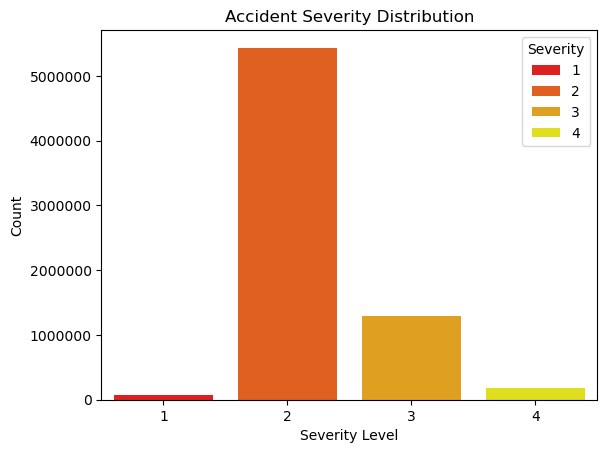

In [151]:
sns.countplot(x='Severity',hue='Severity',data=df, palette='autumn',legend=True)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Key Insights: 
1. It is observed that majority of accidents fall under Severity Level 2, which indicates thats most accidents in the dataset are moderately serious but not extemely severe.
2. It is also observed that high severity accidents Level 3 and Level 4 occur less frequently, suggesting that severe collisions are rare, but still represent safety concerns.

# 2. Temporal Accident Patterns

### 2.1 Accidents by Hour of the Day and Severity

Traffic density changes throughout the day. This visualization helps identify peak hours when accidents occur most frequently.

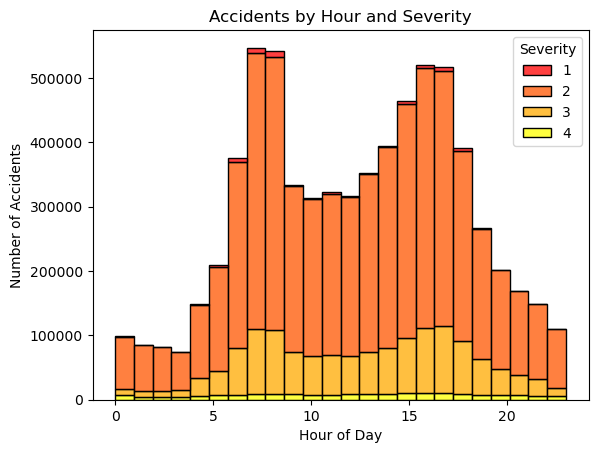

In [139]:
sns.histplot(data=df, x='Hour', bins=24, hue='Severity', palette='autumn', multiple='stack')
plt.title("Accidents by Hour and Severity")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

## Key insights:
1. The distribution of accidents throughout the day shows that, accidents rise sharply between 6 a.m. and 9 a.m., with a stron peak around 7-8 a.m. This implies, traffic volume increases significantly highlighting majority of people commuting for work during morning hours.
2. Second major peak is observered between 3 p.m and 6 p.m, majorly peaking around 4-5 p.m. indicating the evening commuting hours when many people return from work, increasing traffic volume.
3. Most accidents fall under Severity Level 2, indicating moderate collisions but severe accidents of Level 3 and Level 4 increases during the peak traffic hours, leading to serious accidents due to traffic congestion, driver stress and high vehicle interactions
4. Between 10-2 p.m and 11-4 p.m., the accident counts are significantly lower, likely due to less intense commute hours and reduced traffic volume during night time.

### 2.2 Accidents by Day of the week and Rush Hour
This plot examines how accidents are distributed across different days of the week to identify whether weekday commuting or weekend travel patterns influence accident frequency.

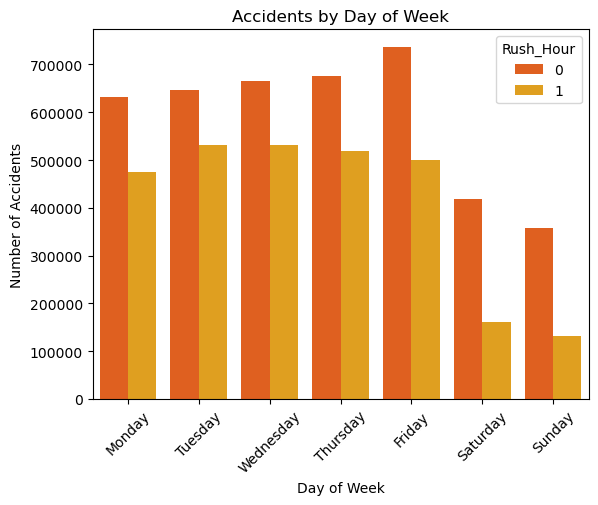

In [140]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='Day_of_Week', data=df, order=days_order,hue='Rush_Hour',palette='autumn', legend=True)

plt.title("Accidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

## Key insights:
1. Accident counts increases steadily from Monday to Friday during weekdays reflecting higher work-related commuting activity. Rush hours are consistently high from Tuesday to Thursday showing peak commuting period.
2. Friday shows largest accident count overall, especially during non rush hours, possibly indicating the weekend travel and increased evening traffic.
3. There is a significant decrease of accidents on Saturday and Sunday, likely due to reduced work commuting by lowering the overall traffic volume. It is prominently observed that rush hour accidents are much lower as compared to weekdays.
4. Significantly, non-rush hours accidents dominates overall, suggesting that accidents occur throughout the day, not only during peak commuting hours.

### 2.3 Accidents by Time of Day and Rush Hour
To better understand traffic patterns, accident occurrences were grouped into four time periods: Morning, Afternoon, Evening, and Night.

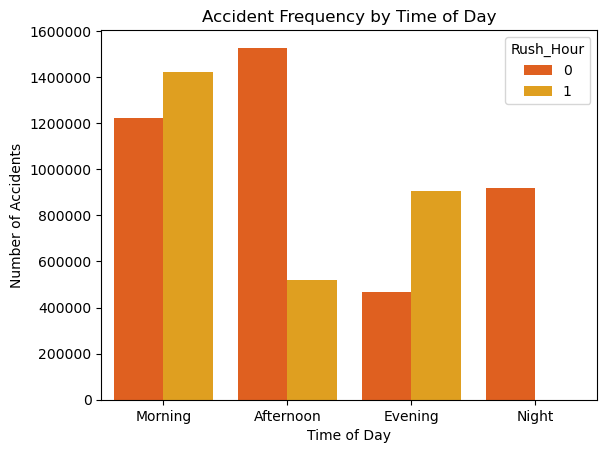

In [141]:
sns.countplot(x='Time_of_Day',data=df, order=['Morning','Afternoon','Evening','Night'],hue='Rush_Hour',palette='autumn', legend = True)
plt.title("Accident Frequency by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.ticklabel_format(style='plain', axis='y')  
plt.show()

## Key insights:
1. Accident frequency is significantly higher during Morning and Evening rush hours refelcting heavy commuter traffic.
2. Afternoon hours reports highest overall accident count, outside non rush hours, likely due to sustained day time traffic from work, school and comerical activites.
3. Night time accdients occur mostly outside rush hours and are comparatively lower indicating reduced traffic volume during late hours.

### 2.4 Accients occuring by Light Conditions



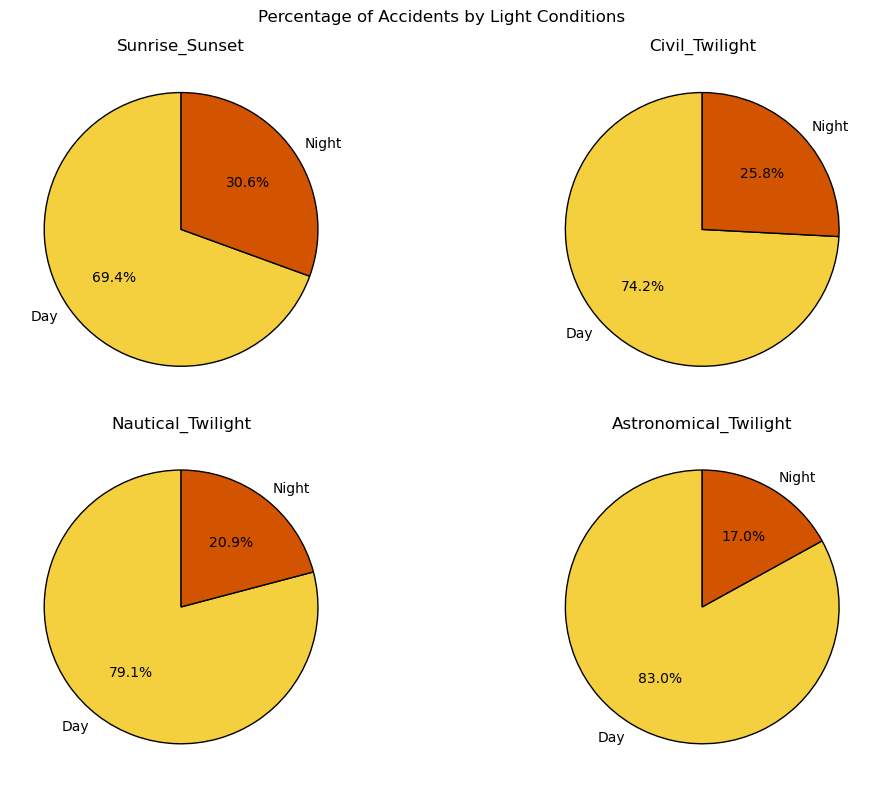

In [142]:
features = ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
fig, axes = plt.subplots(2,2, figsize=(12,8))
colors = ['#F4D03F', '#D35400']  # autumn colors
for ax, feature in zip(axes.flatten(), features):

    counts = df[feature].value_counts()

    ax.pie(counts,labels=counts.index,autopct='%1.1f%%',colors=colors,startangle=90,wedgeprops={'edgecolor':'black'})

    ax.set_title(f"{feature}")

plt.suptitle("Percentage of Accidents by Light Conditions")
plt.tight_layout()
plt.show()

### Key insights
1. It is almost evident that most accidents occur during daylight conditions, which is about 69-83% across all twilight categories, due to higher traffic volume.
2. Night time accidents account for smaller share nearly 17-31%, indicating fewer vehicles on road during darker hours.
3. As lighting conditions become darkerm the percentage of day time accidents increases, suggesting that the accident frequency is mostly strongly influenced by traffic density rather than lighting conditions alone.

### 2.4 Accident by Month Vs Years
A heatmap is used to visualize how accident frequency varies across months and years.  This helps identify seasonal accident trends and year-to-year variations.

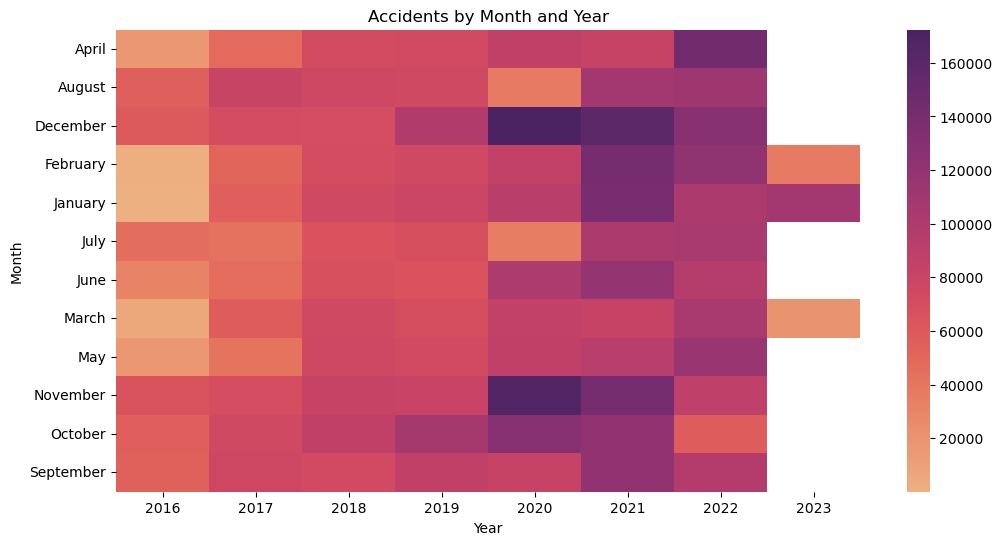

In [143]:
df['Year'] = df['Year'].astype(int)
pivot = df.pivot_table(index='Month', columns='Year', aggfunc='size')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='flare')
plt.title("Accidents by Month and Year")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

### Key insights:
1. This plot serves very crucial information to understand the accdient frequencncy over the years from 2016 to 2023.
2. From 2016 to 2018, there is moderate increase the number of accidents, corresponding to summer travel and holiday seasons (May-July).
3. By the end of 2019 and early COVID-19 impact in 2020, there are noticeable changes in the accident intensity count. In early 2020, many counties imposed stay at home orders and travel restrictions, which lowered the road usage. However it is observered high spikes in the month of November and December (2021), due to gradual reopening of cities and sudden increase in the mobility after lockdown period. This sddden increase can also be due to Christmas, Newyear's eve or Thanksgiving.
4. Post lockdown, year 2021 indicates higher accident counts as compared to 2020, due to reopening of workplaces and travel after long restricition

# 3 Environmental Risk Factors

### 3.1 Accidents by Weather Conditions by Month

Weather conditions play a major role in road safety. This visualization examines how accidents are distributed across different weather categories

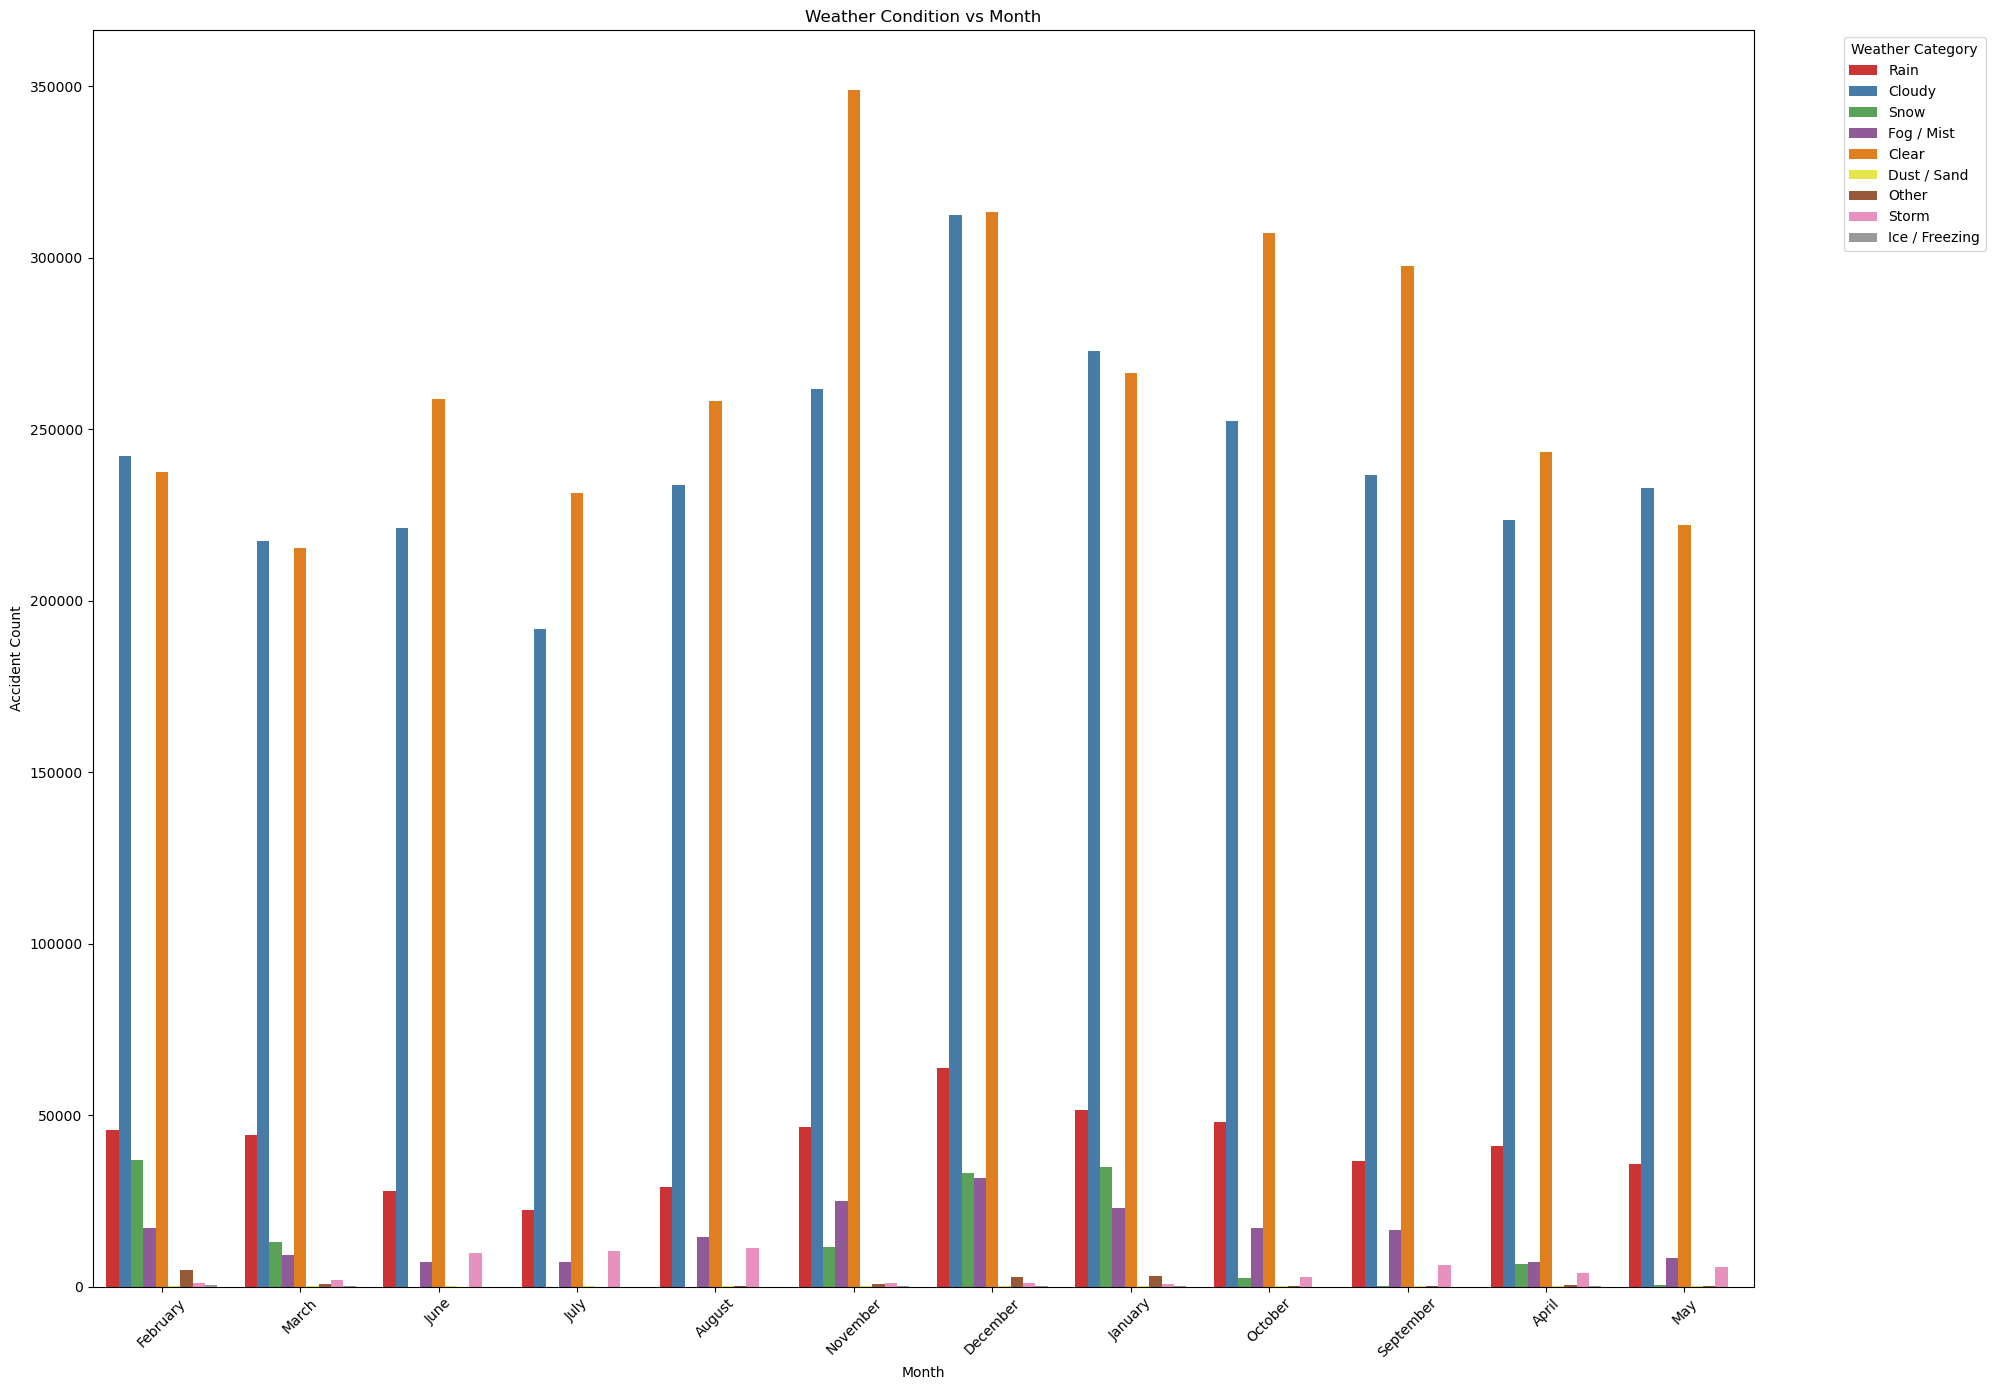

In [144]:
plt.figure(figsize=(20,14))  # increase plot width

sns.countplot(data=df, x='Month', hue='Weather_Category',palette='Set1')

plt.title("Weather Condition vs Month")
plt.xlabel("Month")
plt.ylabel("Accident Count")

plt.xticks(rotation=45)  # rotate month labels
plt.legend(title="Weather Category", bbox_to_anchor=(1.05,1), loc='upper left')  # expand legend space

plt.tight_layout()
plt.show()


### Key insights
1. Across all the months, it is obsevered accidents occuring under clear and cloudy conditions are consistently highest, indicating the accident frequency is primarily driven by traffic volume rather than adverse weather, since more people travel during good weather conditions.
2. Rain related accidents remain consistently high across months, with noticeable peaks in late summer and early winter due to wet roads,  reducing tire friction, making collisions likely to happen more.
3. Snow related accidents increase significantly during winter months, particularly during december and january. As snow creates slippery road surfaces and reduce vehicle control, increasinf accident risk.
4. Weather cateogories such as, Dust/Sand, Storm and Ice/Freezing show much lower accident counts compared to clear or rainy conditions, as this weather, often discourage travel, resulting in overall fewer accdients.

## 3.2 Visibility vs Severity & Wind Speed vs Severity

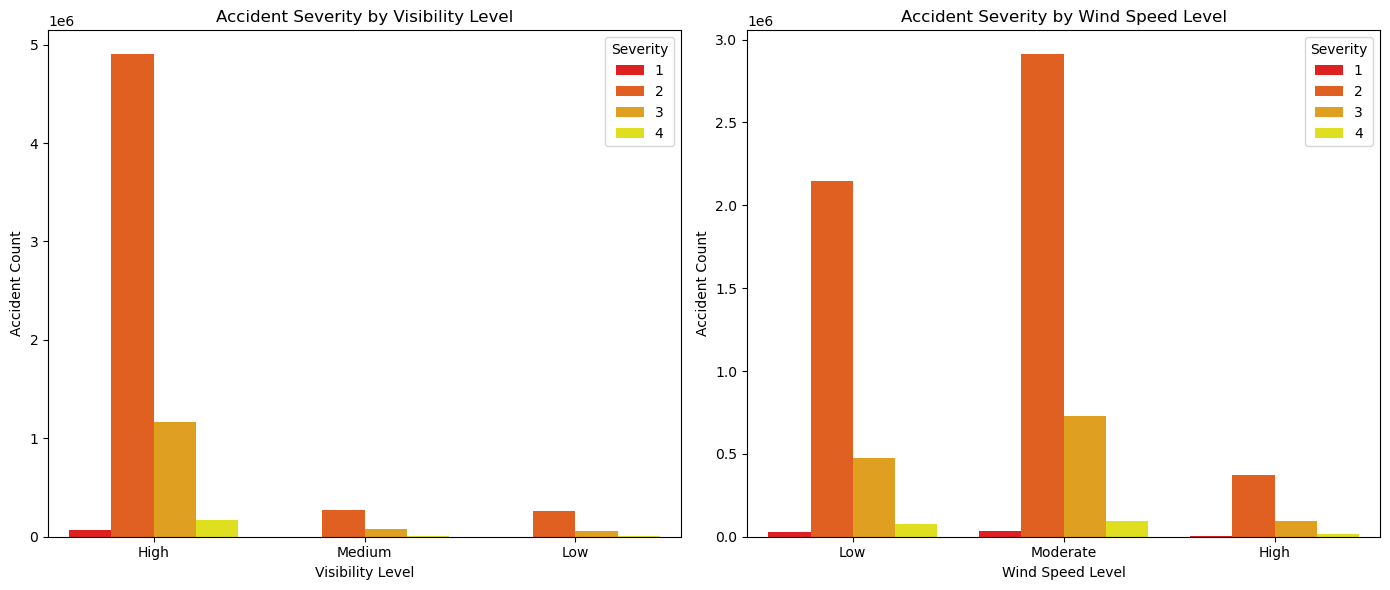

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Visibility vs Severity
sns.countplot(data=df,x='Visibility_Level',hue='Severity',palette='autumn',ax=axes[0])
axes[0].set_title("Accident Severity by Visibility Level")
axes[0].set_xlabel("Visibility Level")
axes[0].set_ylabel("Accident Count")

# Wind Speed vs Severity
sns.countplot(data=df,x='Wind_Level',hue='Severity',palette='autumn',ax=axes[1])
axes[1].set_title("Accident Severity by Wind Speed Level")
axes[1].set_xlabel("Wind Speed Level")
axes[1].set_ylabel("Accident Count")

plt.tight_layout()
plt.show()

### Key insights

1. Most accidents happen when visibility is high, which suggests that accidents are more closely related to higher traffic volume during normal driving conditions rather than poor visibility.
2. Across all visibility levels, Severity Level 2 accidents are the most common, indicating that most crashes tend to be moderately severe rather than extremely serious.
3. Accidents are most frequent when wind speeds are moderate, likely because these conditions occur during typical driving situations when traffic flow is highest.
4. In contrast, very strong winds and low visibility conditions show fewer accidents, possibly because drivers tend to travel less or drive more cautiously during extreme weather conditions.

### 3.3 Accidents Near Road Infrastructure 

Certain road elements such as junctions, traffic signals, bumps, and railway crossings may influence accident occurrence. Pie charts below show the proportion of accidents occurring near these road features.

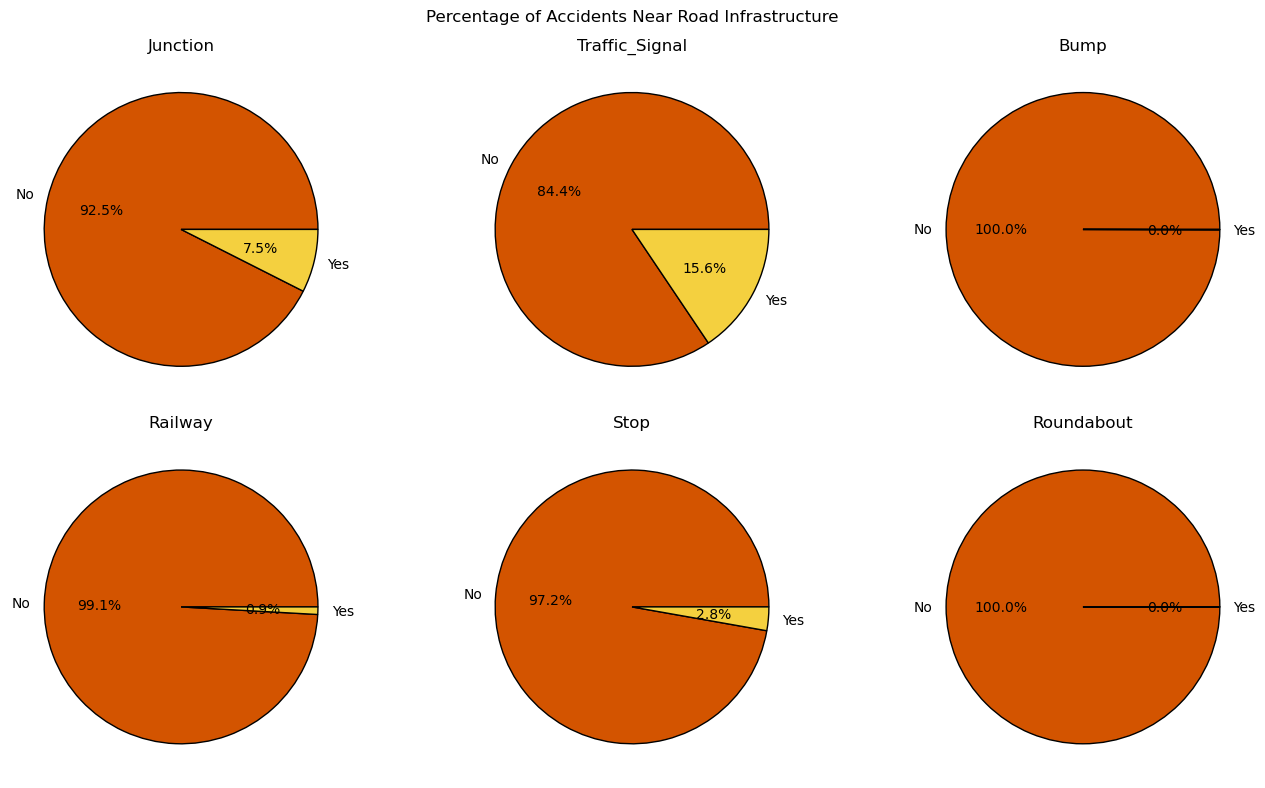

In [146]:
features = ['Junction','Traffic_Signal','Bump','Railway','Stop','Roundabout']

fig, axes = plt.subplots(2,3, figsize=(14,8))

for ax, feature in zip(axes.flatten(), features):

    counts = df[feature].value_counts()

    ax.pie(counts,labels=['No','Yes'],autopct='%1.1f%%',colors=['#D35400','#F4D03F'],wedgeprops={'edgecolor':'black'})

    ax.set_title(feature)

plt.suptitle("Percentage of Accidents Near Road Infrastructure")
plt.tight_layout()
plt.show()

### Key insights
1. Junction: It is observered only small number of accidents occur near junction which implies, large number of accidents happen away from junction areas.
2. Traffic signal: Out of all the road conditions infrastructure, highest share of accidents occur near traffic signals. This indicates that interscetions with signals may still be relatively risky areas due to sudden stopping, turning and congestion.
3. No accidents are recorded near speed bumps and roundabouts, this may indicate the speed bumps  and rounabout are effective in reducing accident.
4. Accidents near railway crossing are vert rare whereas a small fraction of accidents occur near stop signs, suggesting they are not a major accident hotspot in the dataset.

# 4 Top 10 states with most accidents

Accidents were analyzed geographically using state-level visualizations. 

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\658721911.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




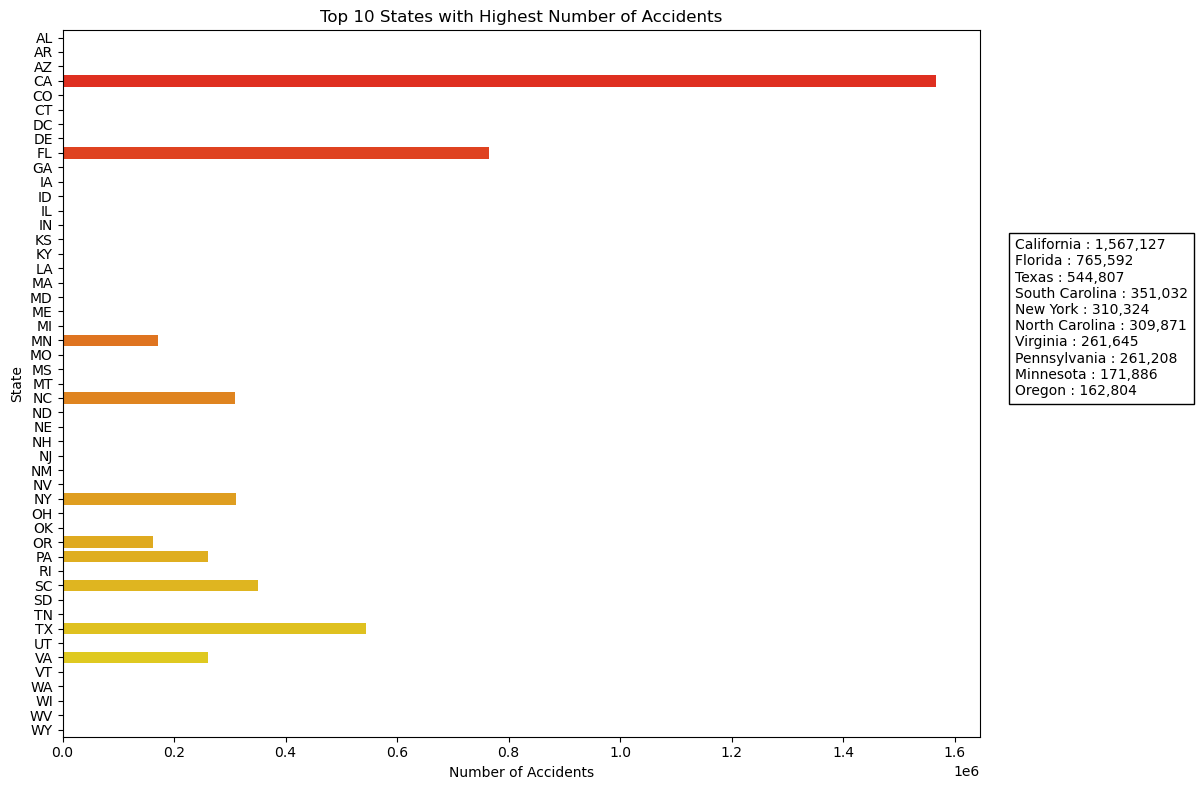

In [147]:
# Top 10 states with most accidents
import matplotlib.ticker as ticker

top_states = df['State'].value_counts().head(10).reset_index()
top_states.columns = ['State', 'Accidents']

plt.figure(figsize=(10,8))

sns.barplot(data=top_states, x='Accidents', y='State', palette='autumn', legend = False)

ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

state_map = {'CA':'California','FL':'Florida','TX':'Texas','NY':'New York','NC':'North Carolina','PA':'Pennsylvania','VA':'Virginia','SC':'South Carolina','MN':'Minnesota','OR':'Oregon'}

legend_text = "\n".join([f"{state_map.get(row.State, row.State)} : {row.Accidents:,}" 
     for _, row in top_states_df.iterrows()])

plt.gcf().text(
    1.02, 0.5,
    legend_text,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black'))

plt.title("Top 10 States with Highest Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("State")

plt.tight_layout()
plt.show()

# 5 Accident Hotspot Map across USA
Geospatial visualization helps identify accident-prone areas by plotting accident locations using latitude and longitude coordinates.

In [148]:
import plotly.express as px
df_geo = df[['Start_Lat','Start_Lng']].dropna()
df_geo['lat_bin'] = np.round(df_geo['Start_Lat'], 1)
df_geo['lng_bin'] = np.round(df_geo['Start_Lng'], 1)
hotspots = df_geo.groupby(['lat_bin','lng_bin']).size().reset_index(name='Accidents')
fig = px.density_mapbox(hotspots,lat='lat_bin',lon='lng_bin',z='Accidents',radius=20,center=dict(lat=39.5, lon=-98.35),zoom=3,mapbox_style="carto-positron",color_continuous_scale="Reds",title="Traffic Accident Hotspots Across the USA")

fig.update_layout(width=1200, height=700)
fig.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_42828\1998627182.py:6: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Key insights:
1. From the accident hotspot map, it is observed that accidents are heavily concentrated in major metroplitan region, with strongest cluster density appearing in South Calorina, Texas, Florida highlighting the impact of dense urban traffic networks.
2. Coastal regions show significantly higher accident density than central states, reflecting higher population concentration, heavy commuting patterns, and extensive highway infrastructure.
3. Midwestern states display moderate accident clusters around major cities, such as Chicago and Detroit, indicating that regional urban hubs also contribute significantly to accident occurrences.
4. Central and sparsely populated states exhibit minimal accident hotspots, likely due to lower traffic density, fewer vehicles, and less congested road networks.
5. Overall, accident density strongly correlates with urbanization and traffic flow, suggesting that traffic management, infrastructure planning, and congestion mitigation strategies are critical for reducing accident frequency.

# Key findings from this project
- Traffic accidents are heavily concentrated in major metropolitan regions, with the strongest clusters appearing in Southern California, the Texas urban corridor, Florida, and the Northeast United States.
- Accident frequency increases significantly during rush-hour commuting periods, highlighting the strong influence of traffic congestion and daily mobility patterns on road safety.
- Urban infrastructure such as intersections, traffic signals, and junctions emerges as a major risk factor, as these locations involve complex vehicle interactions and higher decision-making demands for drivers.
- Adverse weather conditions and reduced visibility contribute to increased accident risk and severity, emphasizing the role of environmental factors in traffic safety.
- Major interstate transportation corridors act as accident concentration zones, indicating that high-volume freight and commuter routes significantly influence accident distribution across the country.